In [ ]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[viz]" aereo-search-aws-goes aereo-read-satpy

In [ ]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_goes19.yaml",
    "config/job_goes19.yaml",
)

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/cordoba.geojson",
    "config/aoi/cordoba.geojson",
)

## Config used in this notebook

This notebook loads the job from `examples/config/job_goes19.yaml`:

```yaml
aoi_path: config/aoi/cordoba.geojson
name: viirs_sample
grid_dist: 50_000
grid_cells_margin: 10
target_aoi: ${aoi_path}
output_uri: /tmp/aereo_extraction
overwrite: false

search:
  _target_: aereo.search_aws_goes.search_aws_goes
  _partial_: true
  collections:
    ABI-L1b-RadF: [C07]
  intersects: ${aoi_path}
  start_datetime: "2026-01-01T15:00:00Z"
  end_datetime: "2026-01-01T15:10:59Z"
  satellites: [GOES-19]
  channels: [C07]

read:
  _partial_: true
  _target_: aereo.read_satpy.read_satpy
  reader: abi_l1b
  wishlist: [C07]

reproject:
  _target_: aereo.builtins.reproject_odc
  _partial_: true
reproject_mode: grid
resolution: 2000

write:
  _target_: aereo.builtins.write.write_geotiff
```


In [1]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_goes19",
)
assets = job.search()

2026-07-08 15:11:09 [info     ] search_called                  provider=search_aws_goes


In [2]:
tasks = job.build_tasks(assets)

2026-07-08 15:11:10 [info     ] build_tasks_start              assets=2 builder=build_grouped_tasks


/root/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


In [3]:
artifacts = job.execute(
    tasks,
    executor=LocalExecutor(workers=-1, cache=TaskResultCache()),
)
print(f"✓ Extracted {len(artifacts)} artifacts")

2026-07-08 15:11:10 [info     ] execute_start                  executor=LocalExecutor task_count=2
2026-07-08 15:11:14 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/OR_ABI-L1b-RadF-M6C07_G19_s20260011510229_e20260011519549_c20260011519594.nc
2026-07-08 15:11:14 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/OR_ABI-L1b-RadF-M6C07_G19_s20260011500229_e20260011509548_c20260011509591.nc
✓ Extracted 34 artifacts


(<Figure size 2000x1591.83 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


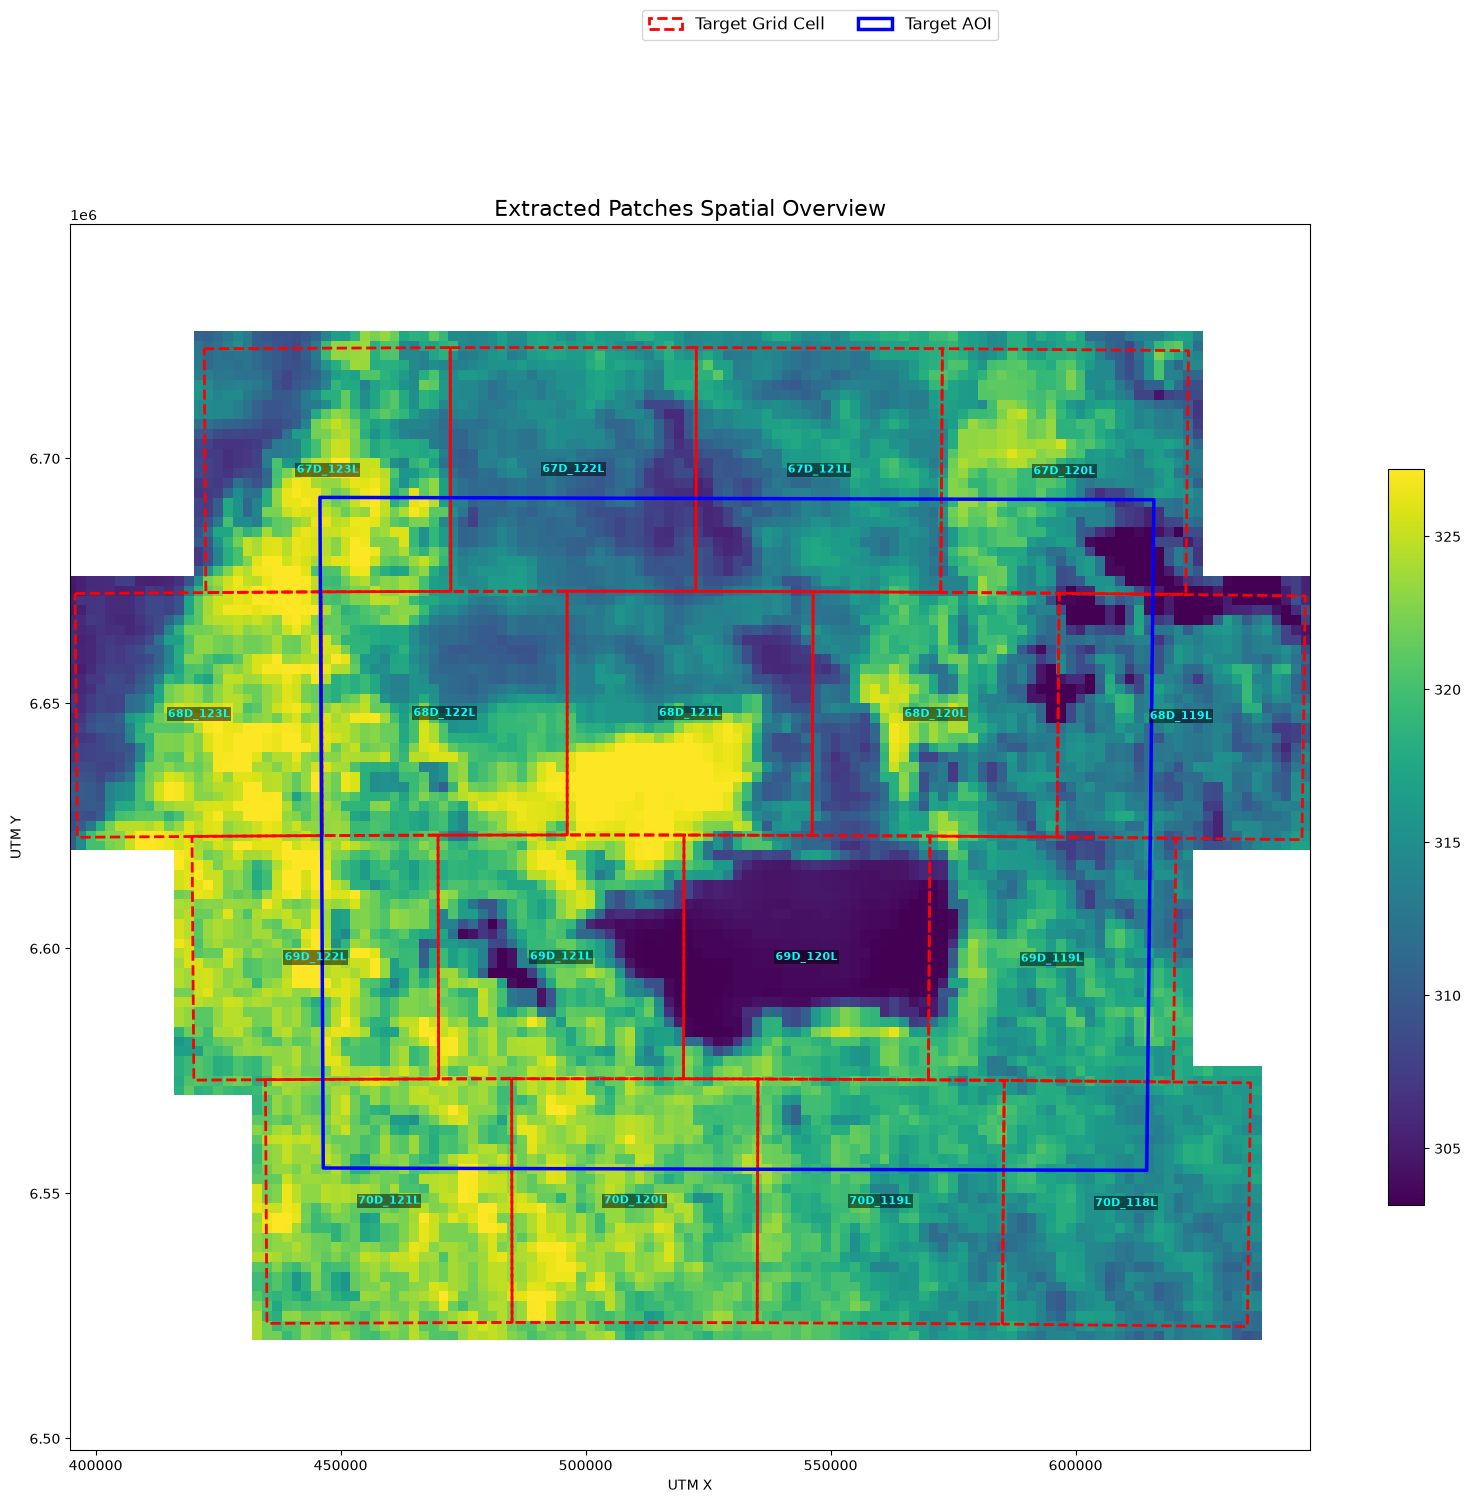

In [4]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(
    artifacts,
    ds_factor=1,
    cmap="viridis",
    stretch="percentile",
    aoi=job.target_aoi,
    aoi_edgecolor="blue",
)